Loading data...
Total rows loaded: 149,715
Years: 2012–2023 | Reporters: ['China', 'China, Hong Kong SAR', 'France', 'Germany', 'Ireland', 'Japan', 'Malaysia', 'Netherlands', 'Rep. of Korea', 'Singapore', 'USA', 'United Kingdom']

Top Exporters (2012–2023):
  China, Hong Kong SAR           $1663.3B
  China                          $1436.3B
  Singapore                      $1122.7B
  Rep. of Korea                  $931.9B
  USA                            $651.6B
  Malaysia                       $592.4B
  Japan                          $551.0B
  Germany                        $266.8B
  Netherlands                    $209.3B
  France                         $104.7B
  Ireland                        $67.1B
  United Kingdom                 $33.4B

Top Importers (2012–2023):
  China                          $2799.7B
  China, Hong Kong SAR           $1449.4B
  USA                            $571.6B
  Singapore                      $559.6B
  Rep. of Korea                  $512.5B
  Malaysia    

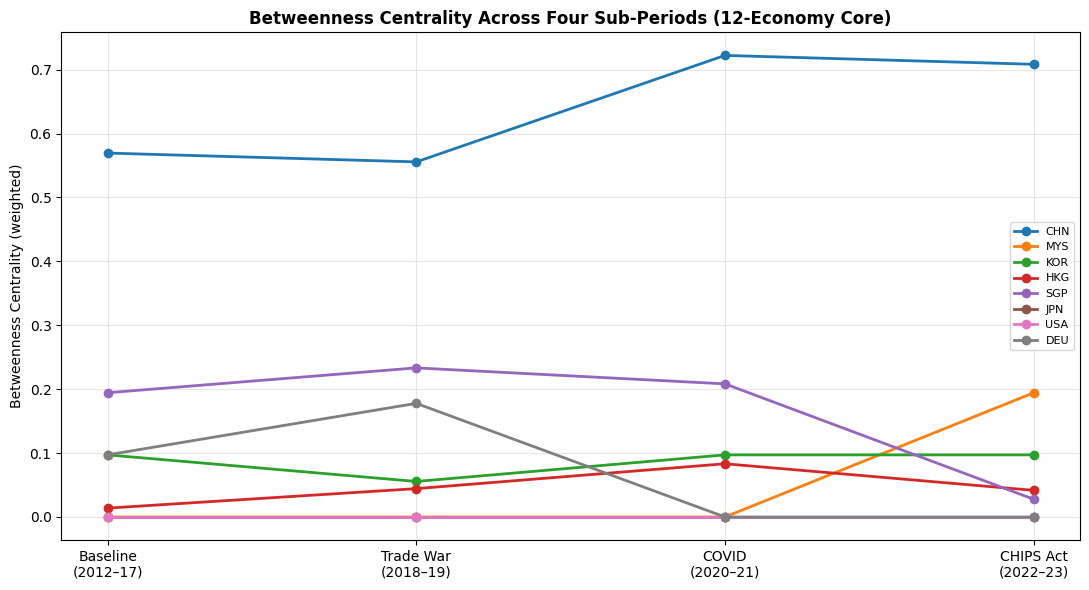

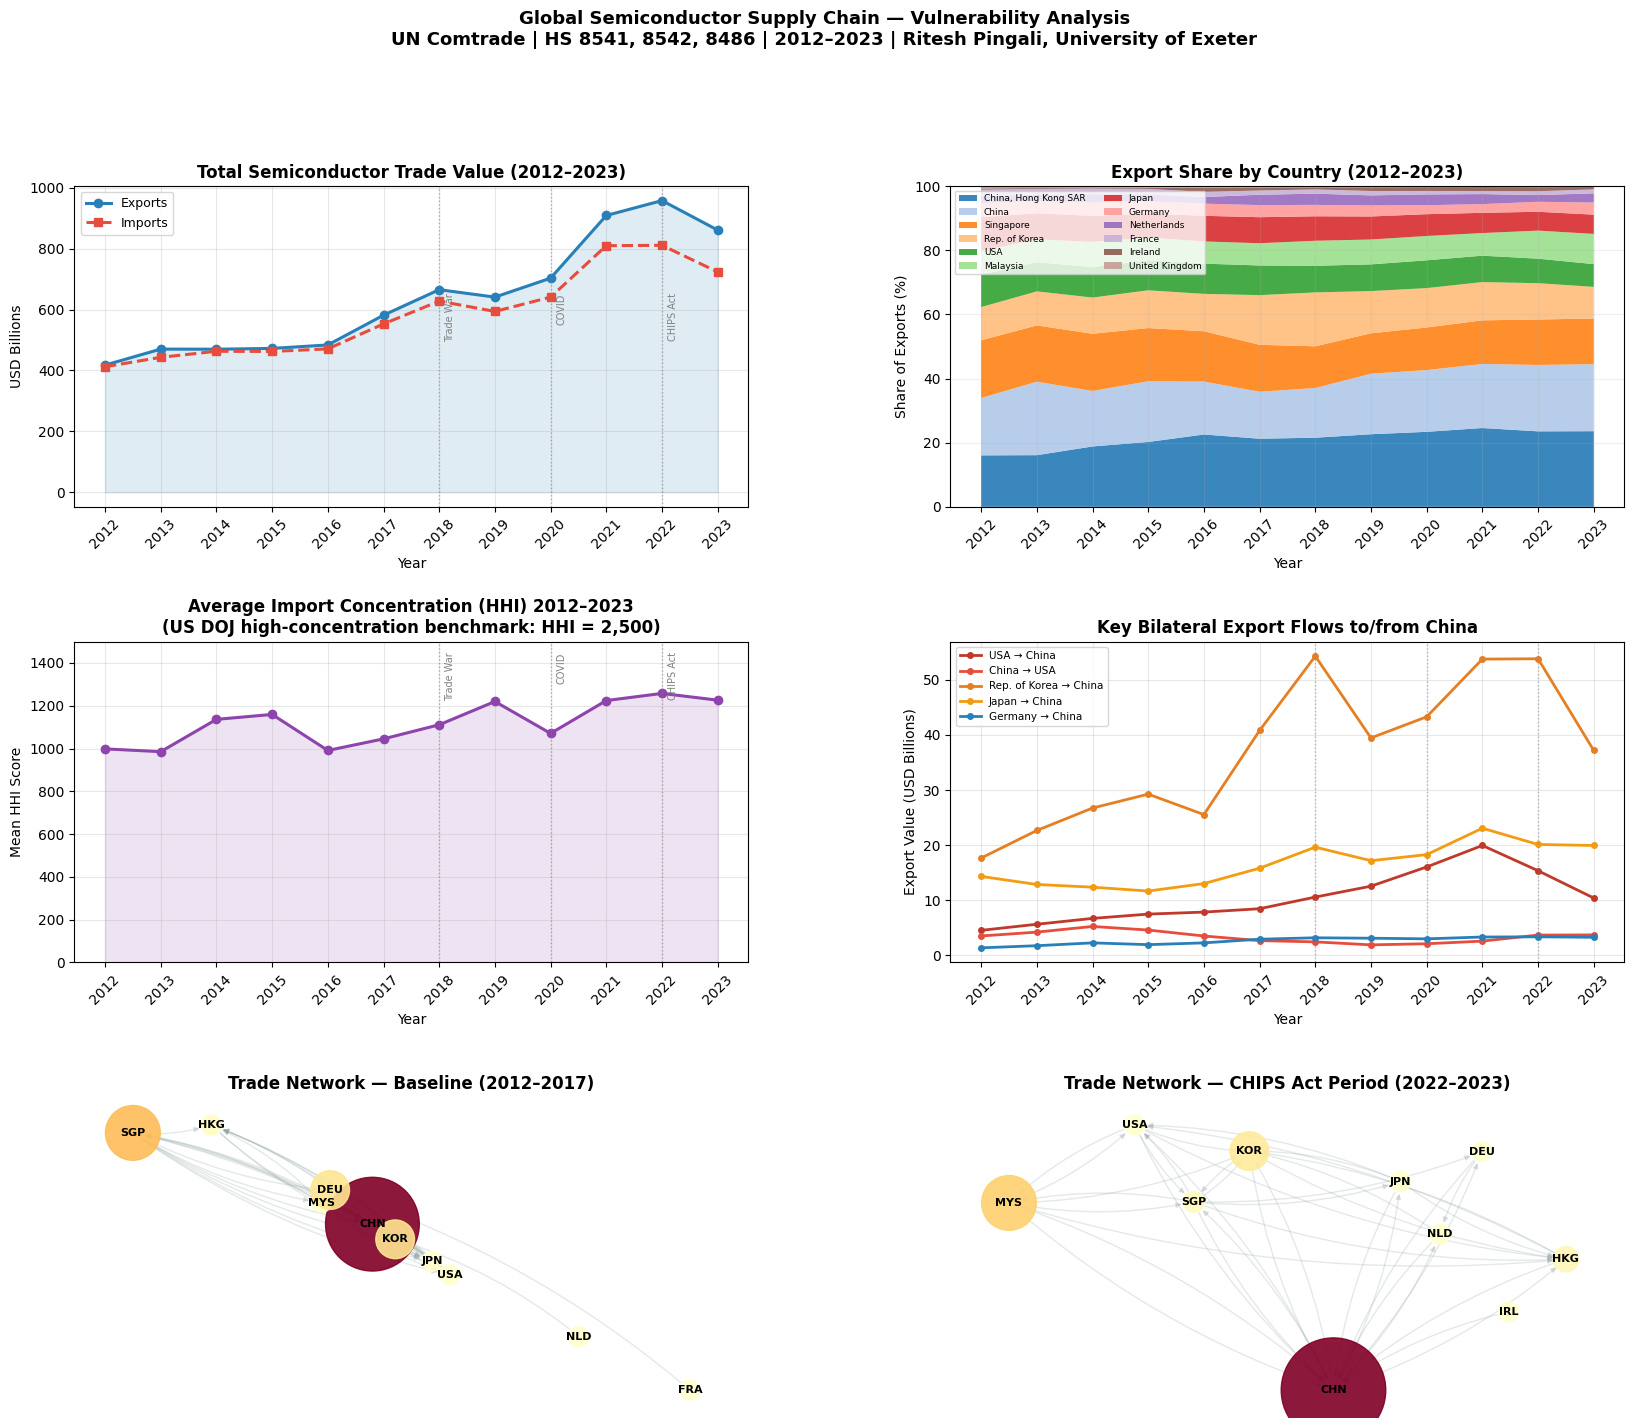


✓ Main figure saved to C:\Users\Ritesh\Desktop\Semiconductor Dissertation\semiconductor_analysis.png
✓ Betweenness trajectory saved to betweenness_four_periods.png
✓ Analysis complete.
Share of semiconductor imports sourced from China (%):
year                  2012  2013  2014  2015  2016  2017  2018  2019  2020  \
reporter                                                                     
China, Hong Kong SAR  29.2  34.5  35.4  36.3  36.0  36.3  34.7  38.4  37.2   
France                15.4  14.8  12.7  12.6  10.9   8.9   8.8  10.1  17.1   
Germany               27.8  18.8  13.5  14.0  14.2  14.9  17.3  19.0  22.5   
Ireland                4.3   3.0   1.9   1.7   6.4  10.8   5.0   4.4   6.4   
Japan                 21.9  30.1  36.9  31.5  30.3  25.9  24.2  29.1  28.4   
Malaysia              17.3  21.1  21.8  19.8  17.9  18.4  19.9  21.7  20.9   
Netherlands           24.8  11.5  10.4   7.7   6.7   3.1   4.6   8.4  11.0   
Rep. of Korea         19.7  21.0  24.4  34.0  32.0  27.0 

In [6]:
"""
Semiconductor Supply Chain Vulnerability Analysis
MSc Dissertation — Ritesh Pingali, University of Exeter
UN Comtrade | HS 8541, 8542, 8486 | 2012–2023

Consolidated version:
  - Four sub-period network analysis (Baseline / Trade War / COVID / CHIPS Act)
  - 12-economy core network with inverse-value distance weighting
  - Threshold vs no-threshold sensitivity check
  - Corrected plot titles, node sizing, colours
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

# ── CONFIGURATION — update this path if you move the folder ──────────────────

FOLDER = r"C:\Users\Ritesh\Desktop\Semiconductor Dissertation"

FILES = [
    "TradeData_6_22_2026_21_34_47.csv",  # 2023
    "TradeData_6_22_2026_21_34_35.csv",  # 2022
    "TradeData_6_22_2026_21_34_22.csv",  # 2021
    "TradeData_6_22_2026_21_34_13.csv",  # 2020
    "TradeData_6_22_2026_21_33_57.csv",  # 2019
    "TradeData_6_22_2026_21_33_46.csv",  # 2018
    "TradeData_6_22_2026_21_33_33.csv",  # 2017
    "TradeData_6_22_2026_21_5_35.csv",   # 2016
    "TradeData_6_22_2026_21_5_22.csv",   # 2015
    "TradeData_6_22_2026_21_5_11.csv",   # 2014
    "TradeData_6_22_2026_20_58_55.csv",  # 2013
    "TradeData_6_22_2026_20_57_34.csv",  # 2012
]

full_paths = [os.path.join(FOLDER, f) for f in FILES]

# ── 1. LOAD ───────────────────────────────────────────────────────────────────

print("Loading data...")
df = pd.concat([pd.read_csv(f, encoding='latin1', low_memory=False) for f in full_paths],
               ignore_index=True)
print(f"Total rows loaded: {len(df):,}")

# ── 2. CLEAN ──────────────────────────────────────────────────────────────────

df = df.rename(columns={
    'refPeriodId': 'year',
    'reporterISO': 'reporter',
    'reporterCode': 'reporter_iso',
    'partnerISO':  'partner',
    'partnerCode': 'partner_iso',
    'flowCode':    'flow',
    'fobvalue':    'value_usd',
})

df = df[
    (df['partner'] != 'World') &
    (~df['partner'].str.contains('nes', na=False)) &
    (df['value_usd'] > 0) &
    (df['cmdCode'] != 'All Commodities')
].copy()

def hs_label(desc):
    desc = str(desc)
    if 'manufacture of semiconductor' in desc: return '8486 — Mfg Equipment'
    if 'Diodes' in desc:                       return '8541 — Diodes/Transistors'
    if 'microassemblies' in desc:              return '8542 — ICs (legacy)'
    if 'integrated circuits' in desc.lower():  return '8542 — Integrated Circuits'
    return desc[:35]

df['hs_label'] = df['cmdCode'].apply(hs_label)

exports = df[df['flow'] == 'Export'].copy()
imports = df[df['flow'] == 'Import'].copy()

YEARS = sorted(df['year'].unique())
print(f"Years: {YEARS[0]}–{YEARS[-1]} | Reporters: {sorted(df['reporter'].unique())}")

# ── 3. TRADE VALUE BY YEAR ────────────────────────────────────────────────────

yearly_exp = exports.groupby('year')['value_usd'].sum()
yearly_imp = imports.groupby('year')['value_usd'].sum()

# ── 4. TOP EXPORTERS / IMPORTERS ─────────────────────────────────────────────

top_exp = exports.groupby('reporter')['value_usd'].sum().sort_values(ascending=False)
top_imp = imports.groupby('reporter')['value_usd'].sum().sort_values(ascending=False)

print("\nTop Exporters (2012–2023):")
for c, v in top_exp.items(): print(f"  {c:<30} ${v/1e9:.1f}B")

print("\nTop Importers (2012–2023):")
for c, v in top_imp.items(): print(f"  {c:<30} ${v/1e9:.1f}B")

# ── 5. HHI IMPORT CONCENTRATION BY YEAR ──────────────────────────────────────

def hhi(group):
    total = group['value_usd'].sum()
    if total == 0: return np.nan
    s = group['value_usd'] / total
    return round((s**2).sum() * 10000, 1)

hhi_yearly = (imports.groupby(['year', 'reporter'])
              .apply(hhi).reset_index()
              .rename(columns={0: 'hhi'}))

hhi_system = hhi_yearly.groupby('year')['hhi'].mean()

# ── 6. BILATERAL TRADE FLOWS ──────────────────────────────────────────────────

key_pairs = [
    ('USA', 'China'),
    ('China', 'USA'),
    ('Rep. of Korea', 'China'),
    ('Japan', 'China'),
    ('Germany', 'China'),
]

pair_trends = {}
for reporter, partner in key_pairs:
    trend = (exports[(exports['reporter'] == reporter) & (exports['partner'] == partner)]
             .groupby('year')['value_usd'].sum() / 1e9)
    pair_trends[f"{reporter} → {partner}"] = trend

# ── 7. NETWORK ANALYSIS — FOUR SUB-PERIODS, 12-ECONOMY CORE ──────────────────

PERIODS = {
    'Baseline\n(2012–17)':  list(range(2012, 2018)),
    'Trade War\n(2018–19)': [2018, 2019],
    'COVID\n(2020–21)':     [2020, 2021],
    'CHIPS Act\n(2022–23)': [2022, 2023],
}

# ISO3 codes for the 12 economies
CORE_ISO = {'CHN', 'HKG', 'SGP', 'KOR', 'USA', 'MYS',
            'JPN', 'DEU', 'NLD', 'FRA', 'IRL', 'GBR'}

def build_period_network(year_list, threshold=0.70):
    """12-economy core network.
    Annual-average edge weights; optional percentile threshold;
    inverse-value 'distance' attribute for weighted betweenness.
    Set threshold=None to keep all edges (sensitivity check)."""
    period_data = exports[
        exports['year'].isin(year_list) &
        exports['reporter_iso'].isin(CORE_ISO) &
        exports['partner_iso'].isin(CORE_ISO)
    ]
    edges = (period_data.groupby(['reporter_iso', 'partner_iso'])['value_usd']
             .sum().reset_index())
    edges['value_usd'] = edges['value_usd'] / len(year_list)   # annual average
    if threshold is not None:
        edges = edges[edges['value_usd'] >= edges['value_usd'].quantile(threshold)]
    G = nx.DiGraph()
    for _, r in edges.iterrows():
        G.add_edge(r['reporter_iso'], r['partner_iso'],
                   weight=r['value_usd'],
                   distance=1.0 / r['value_usd'])   # strong link = short path
    return G

def betweenness_tables(networks):
    bc_w = {p: nx.betweenness_centrality(G, weight='distance')
            for p, G in networks.items()}
    bc_u = {p: nx.betweenness_centrality(G, weight=None)
            for p, G in networks.items()}
    bc_w_df = pd.DataFrame(bc_w).round(4).fillna(0)
    bc_u_df = pd.DataFrame(bc_u).round(4).fillna(0)
    return bc_w_df, bc_u_df

# — Main specification: 70th-percentile threshold —
networks = {p: build_period_network(yrs) for p, yrs in PERIODS.items()}
bc_w_df, bc_u_df = betweenness_tables(networks)

print("\n" + "=" * 70)
print("MAIN SPECIFICATION — 70th percentile threshold")
print("=" * 70)
print("\nWeighted betweenness (inverse-value distance):")
print(bc_w_df.sort_values(bc_w_df.columns[-1], ascending=False))
print("\nUnweighted betweenness:")
print(bc_u_df.sort_values(bc_u_df.columns[-1], ascending=False))

# — Sensitivity check: no threshold (all edges retained) —
networks_full = {p: build_period_network(yrs, threshold=None)
                 for p, yrs in PERIODS.items()}
bc_w_full_df, bc_u_full_df = betweenness_tables(networks_full)

print("\n" + "=" * 70)
print("SENSITIVITY CHECK — no threshold (all core edges)")
print("=" * 70)
print("\nWeighted betweenness (inverse-value distance):")
print(bc_w_full_df.sort_values(bc_w_full_df.columns[-1], ascending=False))
print("\nUnweighted betweenness:")
print(bc_u_full_df.sort_values(bc_u_full_df.columns[-1], ascending=False))

# Aliases used by the network panels in the main figure
G_pre   = networks['Baseline\n(2012–17)']
G_post  = networks['CHIPS Act\n(2022–23)']
bc_pre  = bc_w_df['Baseline\n(2012–17)'].to_dict()
bc_post = bc_w_df['CHIPS Act\n(2022–23)'].to_dict()

# ── 7B. BETWEENNESS TRAJECTORY PLOT ──────────────────────────────────────────

fig7, ax7 = plt.subplots(figsize=(11, 6))
x = range(len(PERIODS))
top8 = bc_w_df.sort_values(bc_w_df.columns[-1], ascending=False).index[:8]
for country in top8:
    ax7.plot(x, bc_w_df.loc[country], marker='o', linewidth=2, label=country)
ax7.set_xticks(list(x)); ax7.set_xticklabels(PERIODS.keys())
ax7.set_ylabel('Betweenness Centrality (weighted)')
ax7.set_title('Betweenness Centrality Across Four Sub-Periods (12-Economy Core)',
              fontweight='bold')
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, 'betweenness_four_periods.png'), dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

# ── 8. MAIN FIGURE ───────────────────────────────────────────────────────────

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Global Semiconductor Supply Chain — Vulnerability Analysis\n'
             'UN Comtrade | HS 8541, 8542, 8486 | 2012–2023 | '
             'Ritesh Pingali, University of Exeter',
             fontsize=13, fontweight='bold', y=0.99)

gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.3)

EVENT_YEARS = [(2018, 'Trade War'), (2020, 'COVID'), (2022, 'CHIPS Act')]

# Plot 1: Trade value trend
ax1 = fig.add_subplot(gs[0, 0])
ax1.fill_between(yearly_exp.index, yearly_exp.values / 1e9, alpha=0.15, color='#2980b9')
ax1.plot(yearly_exp.index, yearly_exp.values / 1e9, marker='o', color='#2980b9',
         linewidth=2.2, label='Exports')
ax1.plot(yearly_imp.index, yearly_imp.values / 1e9, marker='s', color='#e74c3c',
         linewidth=2.2, linestyle='--', label='Imports')
for yr, label in EVENT_YEARS:
    ax1.axvline(yr, color='grey', linestyle=':', alpha=0.6, linewidth=1)
    ax1.text(yr + 0.1, ax1.get_ylim()[1] * 0.65, label, fontsize=7,
             color='grey', rotation=90, va='top')
ax1.set_title('Total Semiconductor Trade Value (2012–2023)', fontweight='bold')
ax1.set_xlabel('Year'); ax1.set_ylabel('USD Billions')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.set_xticks(YEARS); ax1.tick_params(axis='x', rotation=45)

# Plot 2: Export share stacked area — distinct colours, ordered by size
ax2 = fig.add_subplot(gs[0, 1])
share_data = exports.groupby(['year', 'reporter'])['value_usd'].sum().unstack(fill_value=0)
share_pct  = share_data.div(share_data.sum(axis=1), axis=0) * 100
ordered_cols = share_data.sum().sort_values(ascending=False).index.tolist()
palette = [cm.tab20(i) for i in range(len(ordered_cols))]
ax2.stackplot(share_pct.index,
              [share_pct[c] for c in ordered_cols],
              labels=ordered_cols,
              colors=palette,
              alpha=0.88)
ax2.set_title('Export Share by Country (2012–2023)', fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('Share of Exports (%)')
ax2.legend(loc='upper left', fontsize=6.5, ncol=2)
ax2.set_xticks(YEARS); ax2.tick_params(axis='x', rotation=45)
ax2.set_ylim(0, 100)
ax2.grid(alpha=0.2)

# Plot 3: HHI system trend — tightened y-axis so variation is visible
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(hhi_system.index, hhi_system.values, marker='o', color='#8e44ad', linewidth=2.2)
ax3.fill_between(hhi_system.index, hhi_system.values, alpha=0.15, color='#8e44ad')
for yr, label in EVENT_YEARS:
    ax3.axvline(yr, color='grey', linestyle=':', alpha=0.6, linewidth=1)
    ax3.text(yr + 0.1, 1450, label, fontsize=7,
             color='grey', rotation=90, va='top')
ax3.set_ylim(0, 1500)   # HHI=2500 benchmark noted in caption instead
ax3.set_title('Average Import Concentration (HHI) 2012–2023\n'
              '(US DOJ high-concentration benchmark: HHI = 2,500)',
              fontweight='bold')
ax3.set_xlabel('Year'); ax3.set_ylabel('Mean HHI Score')
ax3.grid(alpha=0.3)
ax3.set_xticks(YEARS); ax3.tick_params(axis='x', rotation=45)

# Plot 4: Key bilateral flows
ax4 = fig.add_subplot(gs[1, 1])
colors4 = ['#c0392b', '#e74c3c', '#e67e22', '#f39c12', '#2980b9']
for (pair, trend), color in zip(pair_trends.items(), colors4):
    if not trend.empty:
        ax4.plot(trend.index, trend.values, marker='o', label=pair,
                 linewidth=2, color=color, markersize=4)
for yr, label in EVENT_YEARS:
    ax4.axvline(yr, color='grey', linestyle=':', alpha=0.5, linewidth=1)
ax4.set_title('Key Bilateral Export Flows to/from China', fontweight='bold')
ax4.set_xlabel('Year'); ax4.set_ylabel('Export Value (USD Billions)')
ax4.legend(fontsize=7.5); ax4.grid(alpha=0.3)
ax4.set_xticks(YEARS); ax4.tick_params(axis='x', rotation=45)

# Plot 5: Network — Baseline (2012–2017)
ax5 = fig.add_subplot(gs[2, 0])
pos_pre   = nx.spring_layout(G_pre, seed=42, k=3)
sizes_pre = [max(bc_pre.get(n, 0) * 8000, 200) for n in G_pre.nodes()]
col_pre   = [bc_pre.get(n, 0) for n in G_pre.nodes()]
nx.draw_networkx_nodes(G_pre, pos_pre, ax=ax5, node_size=sizes_pre,
                       node_color=col_pre, cmap=cm.YlOrRd, alpha=0.9)
nx.draw_networkx_labels(G_pre, pos_pre, ax=ax5, font_size=8, font_weight='bold')
nx.draw_networkx_edges(G_pre, pos_pre, ax=ax5, alpha=0.25, arrows=True,
                       arrowsize=8, edge_color='#95a5a6',
                       connectionstyle='arc3,rad=0.1')
ax5.set_title('Trade Network — Baseline (2012–2017)', fontweight='bold')
ax5.axis('off')

# Plot 6: Network — CHIPS Act Period (2022–2023)
ax6 = fig.add_subplot(gs[2, 1])
pos_post   = nx.spring_layout(G_post, seed=42, k=3)
sizes_post = [max(bc_post.get(n, 0) * 8000, 200) for n in G_post.nodes()]
col_post   = [bc_post.get(n, 0) for n in G_post.nodes()]
nx.draw_networkx_nodes(G_post, pos_post, ax=ax6, node_size=sizes_post,
                       node_color=col_post, cmap=cm.YlOrRd, alpha=0.9)
nx.draw_networkx_labels(G_post, pos_post, ax=ax6, font_size=8, font_weight='bold')
nx.draw_networkx_edges(G_post, pos_post, ax=ax6, alpha=0.25, arrows=True,
                       arrowsize=8, edge_color='#95a5a6',
                       connectionstyle='arc3,rad=0.1')
ax6.set_title('Trade Network — CHIPS Act Period (2022–2023)', fontweight='bold')
ax6.axis('off')

# Save
output_path = os.path.join(FOLDER, 'semiconductor_analysis.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f"\n✓ Main figure saved to {output_path}")
print("✓ Betweenness trajectory saved to betweenness_four_periods.png")
print("✓ Analysis complete.")

# ── 9. CHINA IMPORT SHARE BY ECONOMY AND YEAR ────────────────────────────────

total_imports = imports.groupby(['year', 'reporter'])['value_usd'].sum()
china_imports = (imports[imports['partner'] == 'China']
                 .groupby(['year', 'reporter'])['value_usd'].sum())

china_share = (china_imports / total_imports * 100).round(1)
china_share_table = china_share.unstack('year')

# Drop China's own row (share of imports from itself isn't meaningful)
china_share_table = china_share_table.drop('China', errors='ignore')

print("Share of semiconductor imports sourced from China (%):")
print(china_share_table)

china_share_table.to_csv(os.path.join(FOLDER, 'china_import_share.csv'))

In [5]:
len(df)

81278

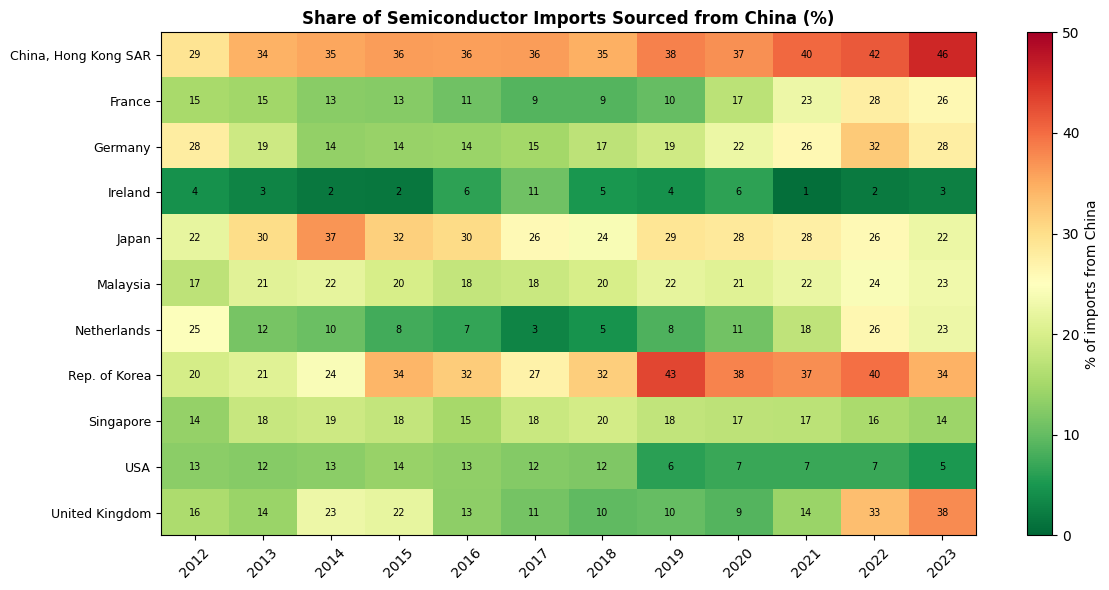

In [7]:
fig9, ax9 = plt.subplots(figsize=(12, 6))
im = ax9.imshow(china_share_table.values, cmap='RdYlGn_r', aspect='auto',
                vmin=0, vmax=50)
ax9.set_xticks(range(len(china_share_table.columns)))
ax9.set_xticklabels(china_share_table.columns, rotation=45)
ax9.set_yticks(range(len(china_share_table.index)))
ax9.set_yticklabels(china_share_table.index, fontsize=9)
for i in range(china_share_table.shape[0]):
    for j in range(china_share_table.shape[1]):
        ax9.text(j, i, f"{china_share_table.values[i, j]:.0f}",
                 ha='center', va='center', fontsize=7)
ax9.set_title('Share of Semiconductor Imports Sourced from China (%)',
              fontweight='bold')
fig9.colorbar(im, ax=ax9, label='% of imports from China')
plt.tight_layout()
plt.savefig(os.path.join(FOLDER, 'china_import_share_heatmap.png'), dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()

In [1]:
import os
os.getcwd()

'C:\\Users\\Ritesh'